### Hiring Salary Prediction

This project uses a small hiring dataset with multiple features, including **experience, test scores, and interview scores**, to predict **salary** using a Multiple Linear Regression model. The experience feature was initially stored as a string and was converted to an integer so it could be used by the model. The relationships between the features and salary were visualized using scatter plots.

The dataset contained only **10 observations**, so this project was primarily used for practice. The model achieved an **R² score of 56%** with a 60% test split. Although this score is relatively low, the small dataset makes the result less reliable. Interestingly, the R² score increased when the test set was larger, showing that model performance can vary significantly with small datasets and different train-test splits.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [22]:
df = pd.read_csv("hiring.csv")
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [23]:
#filling na with zero
df['experience'] = df['experience'].fillna('zero')
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [24]:
#Converting numbers(strings) to numbers(int)
#Once conversion takes place there will be an error
!pip install word2number
from word2number import w2n
df["experience"] = df["experience"].apply(w2n.word_to_num)

In [25]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [26]:
#Finding median
import math
median_test_score = math.floor(df['test_score(out of 10)'].median())
median_test_score

8

In [27]:
#Fill in the na values with median
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(median_test_score)
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


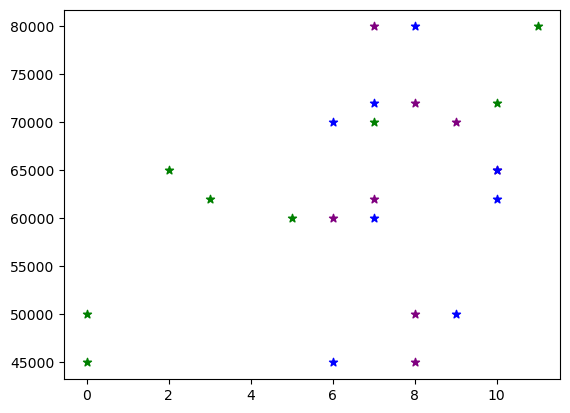

In [28]:
#Scatter plot
#Check if each feature has a linear relationship to salary
%matplotlib inline

plt.scatter(df['experience'], df['salary($)'], color = 'green', marker = '*')

plt.scatter(df['test_score(out of 10)'], df['salary($)'], color = 'purple', marker = '*')

plt.scatter(df['interview_score(out of 10)'], df['salary($)'], color = 'blue', marker = '*')

In [29]:
#train
reg = linear_model.LinearRegression()
reg.fit(df[['experience','test_score(out of 10)', 'interview_score(out of 10)']],df['salary($)'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
reg.predict([[0,7.0,7]])

C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([46093.88646288])

In [31]:
reg.coef_

array([2812.95487627, 1845.70596798, 2205.24017467])

In [32]:
reg.intercept_

np.float64(17737.26346433768)

In [33]:
#Checking m1x+m2x+m3x+b
(2812.95487627*0) + (1845.70596798*7.0) + (2205.24017467*7) + 17737.26346433768


46093.88646288768

Train and Test split practice

In [34]:
from sklearn.model_selection import train_test_split
X = df.drop('salary($)', axis = 1)
y = df['salary($)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

In [35]:
# Checking the split
print(len(X_train))
print(len(X_test))

6
2


In [36]:
#training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
#Prediction is close 
model.predict(X_test)

array([57455.49012816, 63712.15794943])

In [38]:
y_test

2    60000
3    65000
Name: salary($), dtype: int64

r^2 is low

theory: dataset volume is low, test split is to high
test: changing test split

In [39]:
#checking accurarcy/r2
model_accurarcy_r2 = model.score(X_test, y_test)
print(model_accurarcy_r2)

0.34935458919136975


r^2 increased with an increase in test size
test: increase the test-size 

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 10)
model = LinearRegression()
model.fit(X_train, y_train)
model_accurarcy_r2 = model.score(X_test, y_test)
print(f"70/30 split: ", model_accurarcy_r2)

70/30 split:  0.3746420061647464


In [41]:
#Accurarcy went down 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 10)
model = LinearRegression()
model.fit(X_train, y_train)
model_accurarcy_r2 = model.score(X_test, y_test)
print(f"60/40 split: ", model_accurarcy_r2)

60/40 split:  0.13833639593286895


In [42]:
#Accurarcy went down 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 10)
model = LinearRegression()
model.fit(X_train, y_train)
model_accurarcy_r2 = model.score(X_test, y_test)
print(f"50/50 split: ", model_accurarcy_r2)

50/50 split:  0.13833639593286895


In [43]:
#Accurarcy went up 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.6, random_state = 10)
model = LinearRegression()
model.fit(X_train, y_train)
model_accurarcy_r2 = model.score(X_test, y_test)
print(f"40/60 split: ", model_accurarcy_r2)

40/60 split:  0.5625080228036399
